# 05 — Track error: AIFS vs ERA5

For each AIFS initialisation (D-7 through D-1), selects the dominant North
Atlantic cyclone and computes the great-circle distance (km) against the ERA5
ground-truth track at each shared 6-hourly timestep.

Produces:
- **Error vs lead-time** curve
- **Faceted track map** — one panel per lead time, AIFS (red) vs ERA5 (black)

In [ ]:
import pathlib
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
storm_name = "claudia"
era5_tracks_file = "../data/interim/era5_tracks_claudia.csv"
interim_dir = "../data/interim"
atlantic_lat = [25.0, 65.0]
atlantic_lon = [-60.0, 10.0]
output_csv = "../data/processed/track_error_claudia.csv"
output_png = "../data/processed/track_error_claudia.png"
output_maps_png = "../data/processed/track_error_claudia_maps.png"

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

## ERA5 ground-truth track

In [ ]:
era5_df = pd.read_csv(era5_tracks_file, parse_dates=["time"])
era5_truth = era5_df.set_index("time")[["latitude", "longitude"]].sort_index()
print(
    f"ERA5 truth: {era5_truth.index[0]} \u2192 {era5_truth.index[-1]}  ({len(era5_truth)} steps)"
)

ERA5 truth: 2025-11-04 00:00:00 → 2025-11-17 00:00:00  (53 steps)


## AIFS tracks — one per initialisation

In [ ]:
interim_path = pathlib.Path(interim_dir)
aifs_files = sorted(interim_path.glob(f"aifs_tracks_{storm_name.lower()}_*.csv"))
print(f"Found {len(aifs_files)} AIFS track files")

error_rows = []

for fpath in aifs_files:
    aifs_df = pd.read_csv(fpath, parse_dates=["time"])
    if aifs_df.empty:
        continue

    init_date_str = str(aifs_df["init_date"].iloc[0])
    init_date = pd.Timestamp(datetime.strptime(init_date_str, "%Y%m%d%H"))

    # Select dominant track — closest to ERA5 at earliest shared timestep
    # (more robust than min-MSL, which can pick a different, deeper cyclone)
    in_atlantic = aifs_df["latitude"].between(*atlantic_lat) & aifs_df[
        "longitude"
    ].between(*atlantic_lon)
    atlantic_ids = aifs_df.loc[in_atlantic, "track_id"].unique()
    if len(atlantic_ids) == 0:
        print(f"  {init_date_str}: no Atlantic tracks — skipping")
        continue

    best_id = None
    best_dist = np.inf
    for tid in atlantic_ids:
        cand = aifs_df[aifs_df["track_id"] == tid].set_index("time").sort_index()
        overlap = cand.index.intersection(era5_truth.index)
        if len(overlap) == 0:
            continue
        t0 = overlap[0]
        dist = haversine_km(
            era5_truth.loc[t0, "latitude"],
            era5_truth.loc[t0, "longitude"],
            cand.loc[t0, "latitude"],
            cand.loc[t0, "longitude"],
        )
        if dist < best_dist:
            best_dist = dist
            best_id = tid

    if best_id is None:
        print(f"  {init_date_str}: no overlapping Atlantic tracks — skipping")
        continue

    aifs_track = (
        aifs_df[aifs_df["track_id"] == best_id]
        .set_index("time")[["latitude", "longitude"]]
        .sort_index()
    )

    # Stitch continuation segments (same physical cyclone split by tracker)
    stitched_ids = {best_id}
    for _ in range(10):  # max 10 stitching iterations
        last_time = aifs_track.index[-1]
        last_pos = aifs_track.iloc[-1]
        extended = False
        for candidate_id in aifs_df["track_id"].unique():
            if candidate_id in stitched_ids:
                continue
            cand = (
                aifs_df[aifs_df["track_id"] == candidate_id]
                .set_index("time")[["latitude", "longitude"]]
                .sort_index()
            )
            first_time = cand.index[0]
            if first_time <= last_time or (first_time - last_time) > pd.Timedelta(
                "12h"
            ):
                continue
            dist = haversine_km(
                last_pos["latitude"],
                last_pos["longitude"],
                cand.iloc[0]["latitude"],
                cand.iloc[0]["longitude"],
            )
            if dist < 300:
                aifs_track = pd.concat([aifs_track, cand])
                stitched_ids.add(candidate_id)
                extended = True
                break
        if not extended:
            break

    common_times = aifs_track.index.intersection(era5_truth.index)
    if len(common_times) == 0:
        print(f"  {init_date_str}: no overlapping timesteps — skipping")
        continue

    aifs_pts = aifs_track.loc[common_times]
    era5_pts = era5_truth.loc[common_times]
    dist_km = haversine_km(
        era5_pts["latitude"].values,
        era5_pts["longitude"].values,
        aifs_pts["latitude"].values,
        aifs_pts["longitude"].values,
    )

    for t, d in zip(common_times, dist_km):
        error_rows.append(
            {
                "init_date": init_date_str,
                "valid_time": t,
                "lead_time_h": (t - init_date).total_seconds() / 3600,
                "track_error_km": d,
                "aifs_lat": aifs_pts.loc[t, "latitude"],
                "aifs_lon": aifs_pts.loc[t, "longitude"],
                "era5_lat": era5_pts.loc[t, "latitude"],
                "era5_lon": era5_pts.loc[t, "longitude"],
            }
        )

    print(
        f"  {init_date_str}: {len(common_times)} matched steps, mean error={dist_km.mean():.0f} km"
    )

error_df = (
    pd.DataFrame(error_rows)
    .sort_values(["init_date", "valid_time"])
    .reset_index(drop=True)
)
print(f"\n{len(error_df)} rows, {error_df['init_date'].nunique()} initialisations")
error_df.head()

Found 7 AIFS track files
  2025110100: 12 matched steps, mean error=311 km
  2025110200: 21 matched steps, mean error=245 km
  2025110300: 25 matched steps, mean error=123 km
  2025110400: 26 matched steps, mean error=152 km
  2025110500: 28 matched steps, mean error=91 km
  2025110600: 15 matched steps, mean error=43 km
  2025110700: 28 matched steps, mean error=139 km

155 rows, 7 initialisations


,init_date,valid_time,lead_time_h,track_error_km,aifs_lat,aifs_lon,era5_lat,era5_lon
0,2025110100,2025-11-05 06:00:00,102.0,212.002082,41.563902,-92.574607,43.121932,-91.087667
1,2025110100,2025-11-05 12:00:00,108.0,265.776738,41.760037,-87.376085,43.639261,-85.365979
2,2025110100,2025-11-05 18:00:00,114.0,230.997606,41.590312,-79.674919,43.536892,-78.689611
3,2025110100,2025-11-06 00:00:00,120.0,193.614039,41.312493,-74.398638,42.837667,-73.266793
4,2025110100,2025-11-06 06:00:00,126.0,182.188800,41.911864,-69.389678,43.199279,-68.013725


## Faceted track map

Saved → ../data/processed/track_error_claudia_maps.png


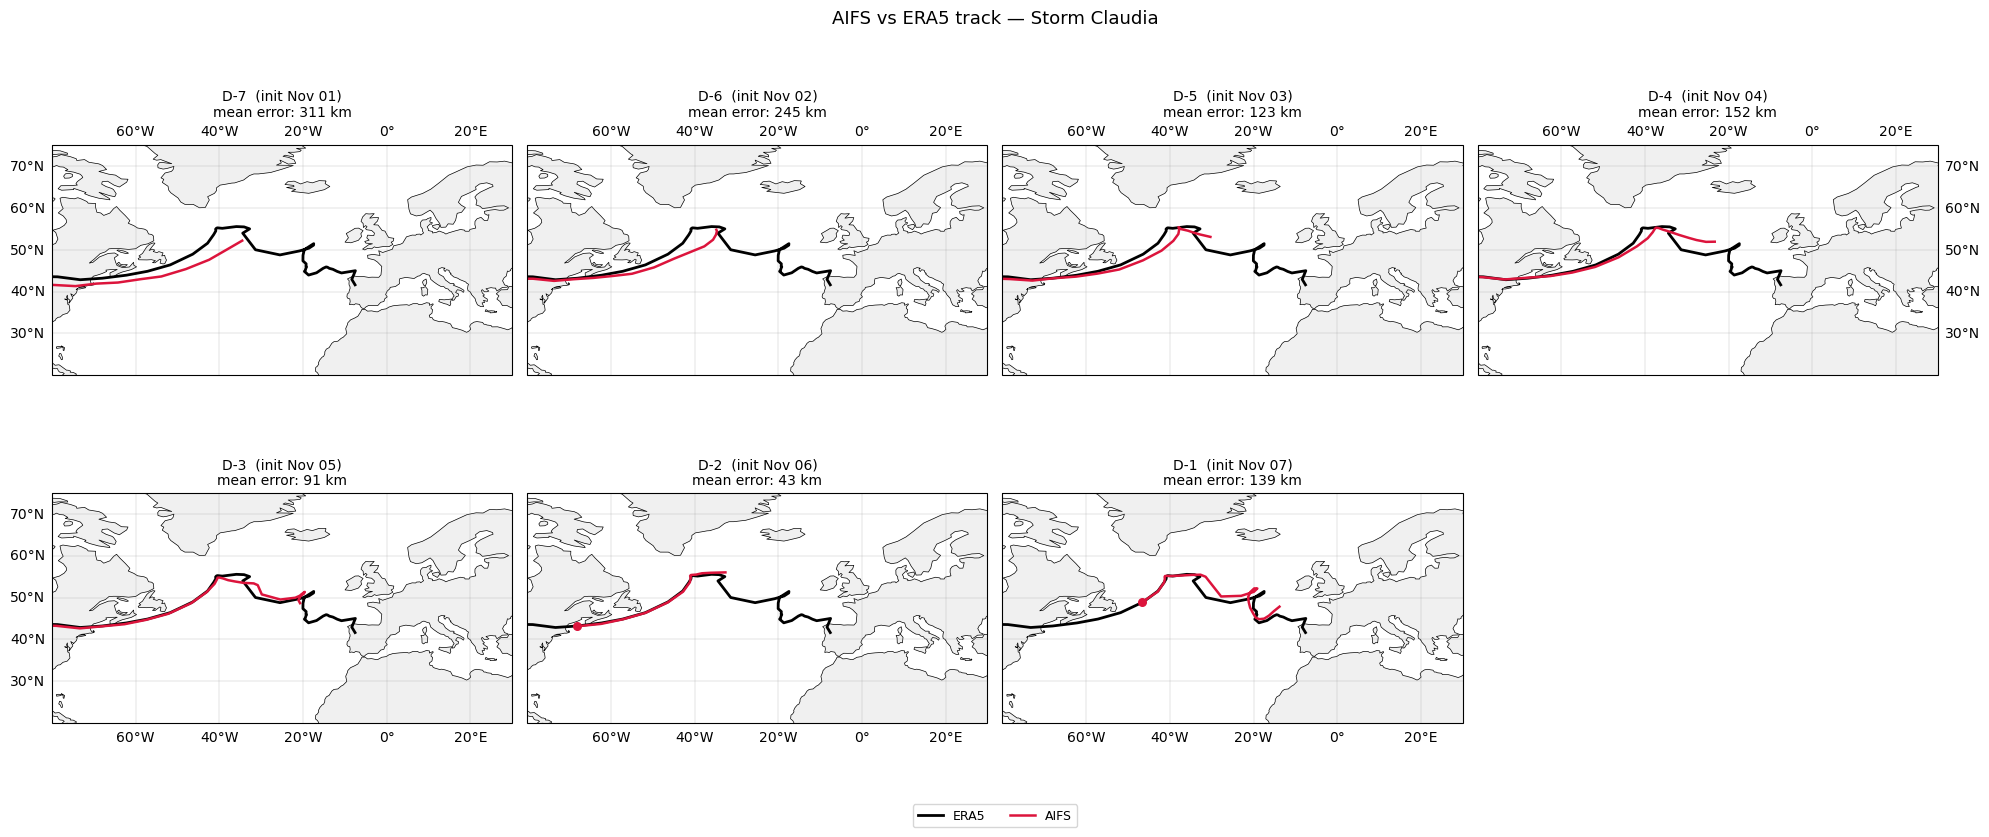

In [ ]:
inits = sorted(error_df["init_date"].unique())
ncols = min(4, len(inits))
nrows = int(np.ceil(len(inits) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    squeeze=False,
)

for idx, (init, ax) in enumerate(zip(inits, axes.flat)):
    _init_ts = pd.Timestamp(datetime.strptime(str(init), "%Y%m%d%H"))
    lead_day = len(inits) - idx
    row, col = divmod(idx, ncols)

    ax.set_extent([-80, 30, 20, 75], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", zorder=0)
    ax.gridlines(
        draw_labels={
            "top": row == 0,
            "bottom": row == nrows - 1,
            "left": col == 0,
            "right": col == ncols - 1,
        },
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        x_inline=False,
        y_inline=False,
    )

    # ERA5 truth (black)
    ax.plot(
        era5_truth["longitude"],
        era5_truth["latitude"],
        color="black",
        linewidth=2,
        label="ERA5",
        transform=ccrs.PlateCarree(),
    )
    ax.scatter(
        era5_truth["longitude"].iloc[0],
        era5_truth["latitude"].iloc[0],
        color="black",
        s=30,
        zorder=5,
        transform=ccrs.PlateCarree(),
    )

    # AIFS forecast (red)
    sub = error_df[error_df["init_date"] == init].sort_values("valid_time")
    if not sub.empty:
        ax.plot(
            sub["aifs_lon"],
            sub["aifs_lat"],
            color="crimson",
            linewidth=1.8,
            label="AIFS",
            transform=ccrs.PlateCarree(),
        )
        ax.scatter(
            sub["aifs_lon"].iloc[0],
            sub["aifs_lat"].iloc[0],
            color="crimson",
            s=30,
            zorder=5,
            transform=ccrs.PlateCarree(),
        )

    mean_err = sub["track_error_km"].mean() if not sub.empty else float("nan")
    ax.set_title(
        f"D-{lead_day}  (init {_init_ts.strftime('%b %d')})\n"
        f"mean error: {mean_err:.0f} km",
        fontsize=10,
    )

for ax in axes.flat[len(inits) :]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02)
)
fig.suptitle(
    f"AIFS vs ERA5 track — Storm {storm_name.capitalize()}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
fig.savefig(output_maps_png, dpi=150, bbox_inches="tight")
print(f"Saved → {output_maps_png}")

## Track error vs lead time

Saved → ../data/processed/track_error_claudia.png


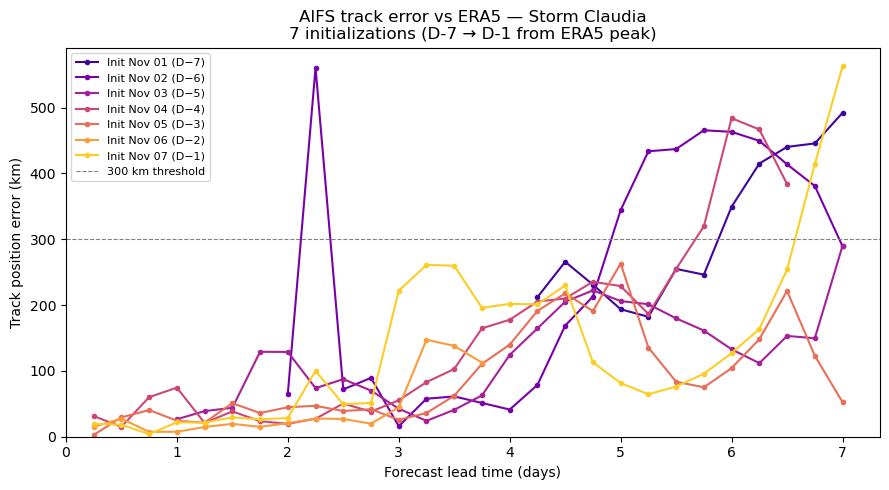

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
inits = sorted(error_df["init_date"].unique())
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(inits)))

for init, color in zip(inits, colors):
    sub = error_df[error_df["init_date"] == init].sort_values("lead_time_h")
    _init_ts = pd.Timestamp(datetime.strptime(str(init), "%Y%m%d%H"))
    ax.plot(
        sub["lead_time_h"] / 24,
        sub["track_error_km"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=color,
        label=f"Init {_init_ts.strftime('%b %d')} (D\u2212{len(inits) - list(inits).index(init)})",
    )

ax.axhline(300, color="grey", linewidth=0.8, linestyle="--", label="300 km threshold")
ax.set_xlabel("Forecast lead time (days)")
ax.set_ylabel("Track position error (km)")
ax.set_title(
    f"AIFS track error vs ERA5 \u2014 Storm {storm_name.capitalize()}\n"
    f"{len(inits)} initializations (D-7 → D-1 from ERA5 peak)"
)
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(output_png, dpi=150)
print(f"Saved → {output_png}")

In [ ]:
error_df.to_csv(output_csv, index=False)
print(f"Saved → {output_csv}")